In [1]:
# Input take label, latent semantics and k
LABEL_INPUT = input(
"""
Provide the label for which you want to find most similar images
"""
)

LATENT_SEMANTICS = input(
"""
Provide a latent semantic that was generated using tasks 3 to 6.
For eg:
if you generated a latent semantic in task 3 from color space and svd,
enter "LS1_color_svd" if you generated it for tasks where you didn't select the algorithm,
use this format "LS3_color"
If you are unsure what to type here, please see Code/database/<name>_reducer.pt
after running the relevant task. Any <name> can be input here.
"""
)

K = int(input("Enter K, the K most similar images to find under the latent space."))

In [35]:
LATENT_SEMANTICS = "LS3_fc_svd"
K = 10
LABEL_INPUT = "airplanes"

In [50]:
import numpy as np
from utils.database_utils import retrieve
from utils.distance_utils import top_k_distance_ranker
from utils.database_utils import compressed_retrieve
from scipy.spatial.distance import cityblock, correlation, cosine, euclidean
from feature_models.feature_matrix.label_label_similarity import LabelLabelSimilarity

In [37]:
from utils.dataset_utils import initialize_dataset
dataset = initialize_dataset()

Files already downloaded and verified


In [38]:
LATENT_SPACE = LATENT_SEMANTICS.split('_')[0]
FEATURE_SPACE = LATENT_SEMANTICS.split('_')[1]

# Load created latent space
reducer = retrieve(f'{LATENT_SEMANTICS}_reducer.pt')

feature_vectors = retrieve(f'{FEATURE_SPACE}.pt')

In [39]:
def find_nearest_cluster(vector, query_vector, K, distance_fn = euclidean):
    distance = []
    for i, feature_item in enumerate(vector.items()):
        image_id, feature_tuple = feature_item
        label = feature_tuple[0]
        current_vector = feature_tuple[1]
        distance.append((image_id, distance_fn(query_vector, current_vector)))
    distance.sort(key=lambda x:x[1])
    return distance[:K]

In [40]:
def get_distances_for_image_latent_space(latent_space):
    centroid_format_latent_space = {}
    for i, feature_item in enumerate(feature_vectors.items()):
        image_id, feature_tuple = feature_item
        label = feature_tuple[0]
        feature = latent_space[i]
        centroid_format_latent_space[image_id] = (label, feature)

    # Find centroids for the labels
    from utils.vector_utils import get_representative_vectors_for_labels
    from utils.dataset_utils import initialize_dataset

    centroids = get_representative_vectors_for_labels(centroid_format_latent_space, initialize_dataset().categories, 1)

    # Find closest labels based on distance
    distances = find_nearest_cluster(centroid_format_latent_space, centroids[LABEL_INPUT], K)
    return distances

In [79]:
if LATENT_SPACE == "LS1":
    # For LS1 find labels for every image in the latent space
    latent_space = reducer.reduce_features(feature_vectors)
    distances = get_distances_for_image_latent_space(latent_space)
    print(distances)

elif LATENT_SPACE == "LS2":
    # For LS2 find labels for every image in the latent space
    latent_space = reducer.image_latent_space_weights
    distances = get_distances_for_image_latent_space(latent_space)
    print(distances)

elif LATENT_SPACE == "LS3":
    # For LS3
    # Get label feature space
    all_labels = initialize_dataset().categories
    label_feature_vectors = retrieve(f'label_label_{FEATURE_SPACE}.pt')

    from utils.vector_utils import get_latent_feature_vectors
    latent_feature_vectors = get_latent_feature_vectors(label_feature_vectors, reducer)

    rep_label_vectors = retrieve(f'rep_label_{FEATURE_SPACE}.pt')

    # Create image label similarity vector
    # for every image in feature vectors
    from utils.vector_utils import get_image_label_similarity_vector
    image_label_feature_space = []
    for i, feature_item in enumerate(feature_vectors.items()):
        image_id, feature_tuple = feature_item
        vector = feature_tuple[1]
        img_label_vector = get_image_label_similarity_vector(vector, rep_label_vectors, all_labels)
        image_label_feature_space.append(img_label_vector)
    image_label_feature_space = np.array(image_label_feature_space)

    # Reduce dimensions for the image label similarity vector and make it into feature vector format
    latent_vector_image_label = reducer.reduce_features({"QUERY": ("UNKNOWN", image_label_feature_space)})[0]
    centroid_format_latent_space = {}
    for i, feature_item in enumerate(feature_vectors.items()):
        image_id, feature_tuple = feature_item
        label = feature_tuple[0]
        feature = latent_vector_image_label[i]
        centroid_format_latent_space[image_id] = (label, feature)

    # Find selected label center
    # First we get label label reduced dimension and then we find the label center we want
    latent_vector_label_label = reducer.reduce_features(label_feature_vectors)
    reference_label_vector = []
    for index, label in enumerate(all_labels):
        if label == LABEL_INPUT:
            reference_label_vector = latent_vector_label_label[index]

    # Find distance between the selected label center and the entire image latent space 
    distances = find_nearest_cluster(centroid_format_latent_space, reference_label_vector, K)
    print(distances)
else:
    image_feature_vectors = compressed_retrieve(f'img_img_{FEATURE_SPACE}.pt')
    latent_space = reducer.reduce_features(image_feature_vectors)
    distances = get_distances_for_image_latent_space(latent_space)
    print(distances)

LS3
Files already downloaded and verified
[(2558, 0.6504023293083963), (2310, 0.6776055595825528), (2116, 0.6780687330216465), (1984, 0.693242389975165), (5602, 0.7059399551132732), (2052, 0.7098191352573157), (2408, 0.7189894398757529), (3902, 0.7235043711127435), (5574, 0.7247440061054543), (2722, 0.727526344836057)]


Image Id: 2558 

Distance Score: 0.6504023293083963


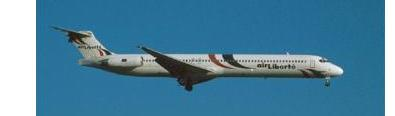

Image Id: 2310 

Distance Score: 0.6776055595825528


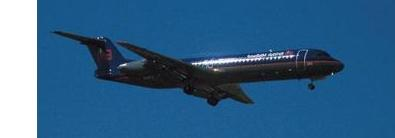

Image Id: 2116 

Distance Score: 0.6780687330216465


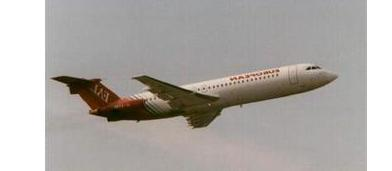

Image Id: 1984 

Distance Score: 0.693242389975165


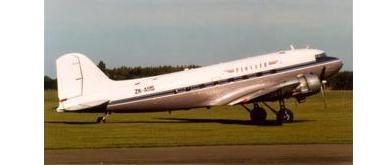

Image Id: 5602 

Distance Score: 0.7059399551132732


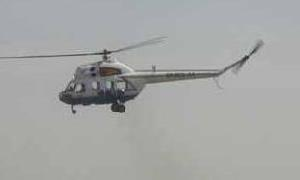

Image Id: 2052 

Distance Score: 0.7098191352573157


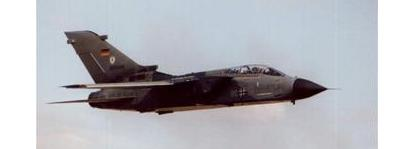

Image Id: 2408 

Distance Score: 0.7189894398757529


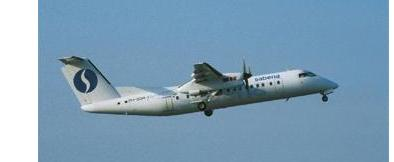

Image Id: 3902 

Distance Score: 0.7235043711127435


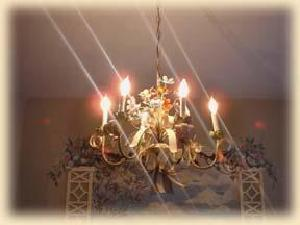

Image Id: 5574 

Distance Score: 0.7247440061054543


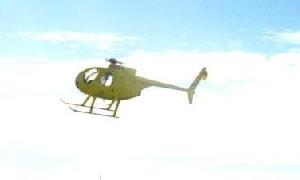

Image Id: 2722 

Distance Score: 0.727526344836057


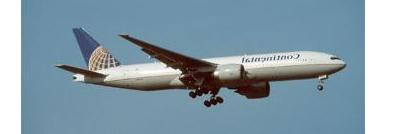

In [80]:
for i in range(len(distances)):
    image_id = distances[i][0]
    distance = distances[i][1]
    print("Image Id:", image_id, "\n\nDistance Score:", distance)
    display(dataset[image_id][0])